In [1]:
import matplotlib.pyplot as plt
%matplotlib widget
from ipywidgets import *
import numpy as np
import pandas as pd
import sys
import taurex.log
taurex.log.disableLogging()
from taurex.cache import OpacityCache,CIACache
from taurex.temperature import Guillot2010
from taurex.planet import Planet
from taurex.stellar import BlackbodyStar, PhoenixStar
from taurex.chemistry import TaurexChemistry, ConstantGas
from taurex.model import TransmissionModel
from taurex.contributions import AbsorptionContribution, CIAContribution, RayleighContribution
from taurex.binning import FluxBinner,SimpleBinner

In [2]:
OpacityCache().clear_cache()
OpacityCache().set_opacity_path("/workspaces/ML_workspace/Taurex/atmosphere/xsecs")
CIACache().set_cia_path("/workspaces/ML_workspace/Taurex/atmosphere/cia/hitran")

h2o_xsec = OpacityCache()['H2O']
ch4_xsec = OpacityCache()['CH4']
co2_xsec = OpacityCache()['CO2']
co_xsec = OpacityCache()['CO']

In [3]:
# Set up the parameters and chemical abundances for the atmospheric model
guillot = Guillot2010(T_irr=284.0)
planet = Planet(planet_radius=0.211,planet_mass=0.028)
star = BlackbodyStar(temperature=3457.0,radius=0.41)
chemistry = TaurexChemistry(fill_gases=['H2','He'], ratio=0.172)
chemistry.addGas(ConstantGas('H2O', mix_ratio=0.00061))
chemistry.addGas(ConstantGas('CH4', mix_ratio=0.00912))
chemistry.addGas(ConstantGas('CO2', mix_ratio=0.01778))
chemistry.addGas(ConstantGas('CO', mix_ratio=0.001))



In [4]:
print(star.radius)

285237000.0


In [5]:
#Build the transmission model and add the contributions from physical processes
tm = TransmissionModel(planet=planet,
                       temperature_profile=guillot,
                       chemistry=chemistry,
                       star=star,
                        atm_min_pressure=1e-0,
                       atm_max_pressure=1e6,
                       nlayers=30)

tm.add_contribution(AbsorptionContribution())
tm.add_contribution(CIAContribution(cia_pairs=['H2-H2','H2-He']))
tm.add_contribution(RayleighContribution())

tm.build()

#Run the model to get the transmission spectrum
res = tm.model()
res

(array([  199.99326855,   200.00660143,   200.01993521, ...,
        33328.88933329, 33331.11125925, 33333.33333333], shape=(76744,)),
 array([0.00296157, 0.00296065, 0.00296017, ..., 0.00295611, 0.00295611,
        0.00295612], shape=(76744,)),
 array([[0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
         8.89014867e-220, 7.68504417e-220, 6.64322615e-220],
        [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
         1.69907625e-144, 1.54379084e-144, 1.40267777e-144],
        [0.00000000e+000, 0.00000000e+000, 0.00000000e+000, ...,
         1.18642861e-094, 1.11433502e-094, 1.04660677e-094],
        ...,
        [9.99957724e-001, 9.99961480e-001, 9.99981535e-001, ...,
         9.97604799e-001, 9.97604105e-001, 9.97603410e-001],
        [9.99989418e-001, 9.99992062e-001, 9.99993174e-001, ...,
         9.98668377e-001, 9.98667991e-001, 9.98667604e-001],
        [9.99996975e-001, 9.99997058e-001, 9.99997829e-001, ...,
         9.99424194e-001, 9.99424027e-001, 9.9

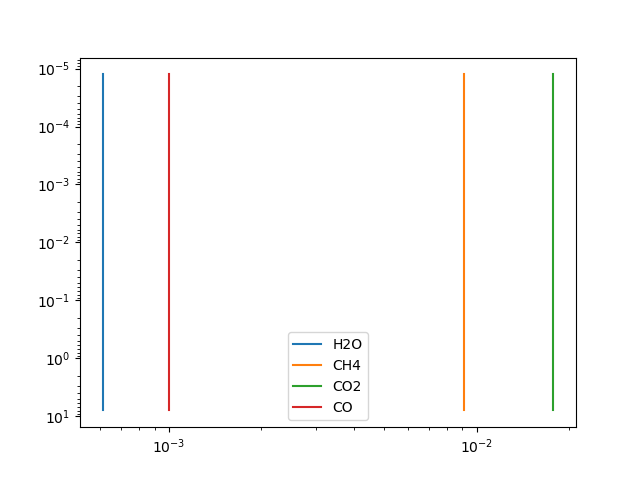

In [6]:
#Plot the atmospheric mixing ratio profiles
plt.figure()

for x,gasname in enumerate(tm.chemistry.activeGases):
    
    plt.plot(tm.chemistry.activeGasMixProfile[x],tm.pressureProfile/1e5,label=gasname)

plt.gca().invert_yaxis()
plt.yscale("log")
plt.xscale("log")
plt.legend()
plt.show()

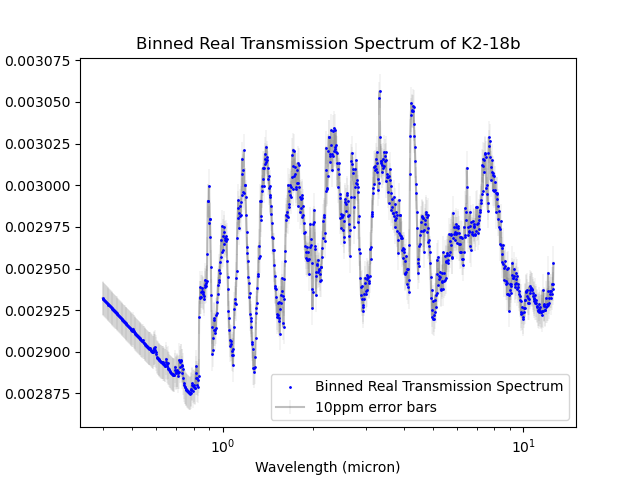

In [7]:
#Plot the binned transmission spectrum
native_grid, rprs, tau, _ = res
binned_fig = plt.figure()


#Make a logarithmic grid
wngrid = np.sort(10000/np.logspace(-0.4,1.1,1000))
bn = SimpleBinner(wngrid=wngrid)

bin_wn, bin_rprs,_,_  = bn.bin_model(tm.model(wngrid=wngrid))
errorbars = np.full_like(bin_rprs, 0.00001)

plt.scatter(10000/bin_wn, bin_rprs, label='Binned Real Transmission Spectrum', c='b', s=1, zorder=1)
plt.errorbar(10000/bin_wn,bin_rprs, yerr=errorbars, label='10ppm error bars', c='k', markersize=2, alpha=0.25, elinewidth=0.25, zorder=-1)
plt.xscale('log')
plt.title('Binned Real Transmission Spectrum of K2-18b')
plt.xlabel('Wavelength (micron)')
plt.ylabel('Radius Ratio (Rp/Rs)')
plt.legend()
plt.show()

In [8]:
#Saving the output spectrum to a file
Data = np.zeros((len(bin_wn),3))
Data[:,0] = 10000/bin_wn
Data[:,1] = bin_rprs
Data[:,2] = errorbars
output_df = np.savetxt('/workspaces/ML_workspace/Tests/K2-18b_assignment3_taskB_spectrum.dat', Data, header='Wavelength(micron) (rp/rs)^2 Error_Bars')

In [9]:
#Saving the plot of the binned transmission spectrum
binned_fig.savefig('/workspaces/ML_workspace/Tests/K2-18b_assignment3_taskB_spectrum.png')

In [10]:
#Saving the input parameters of the model to a text file
with open('/workspaces/ML_workspace/Tests/K2-18b_assignment3_taskB_parameters.txt', 'w') as f:
    f.write("Input Parameters for K2-18b Transmission Model\n")
    f.write("=============================================\n\n")
    f.write("Planet Parameters:\n")
    f.write(f"  Planet Radius (Rj): {0.211}\n")
    f.write(f"  Planet Mass (Mj): {0.028}\n\n")
    
    f.write("Star Parameters:\n")
    f.write(f"  Star Temperature (K): {star.temperature}\n")
    f.write(f"  Star Radius (Rs): {0.41}\n\n")
    
    f.write("Temperature Profile:\n")
    f.write(f"  Irradiation Temperature (T_irr): {guillot.T_irr}\n\n")
    
    f.write("Chemistry of the atmosphere (all values in log10 of Volume Mixing Ratio):\n")
    f.write("CH4: -2.04\n")
    f.write("CO2: -1.75\n")
    f.write("CO: -3.21\n")
    f.write("H2O: -3.00\n")
    f.write("Reference paper for abundances: Madhusudhan et al. 2023, https://arxiv.org/abs/2309.05566\n")

In [12]:
df = pd.read_csv('/workspaces/ML_workspace/PACMAN/file_dump/table_K2-18-b-Madhusudhan-et-al.-2023.csv')

c = [f'CENTRALWAVELNG']
r = [f'PL_TRANDEP']
e = [f'PL_TRANDEPERR']

central_wavelength = df[c].values
pl_trandep = df[r].values
pl_trandep_err = df[e].values


In [13]:
#Saving the output spectrum to a file
Data = np.zeros((3401, 3))
Data[:,0] = central_wavelength[:,0]
Data[:,1] = pl_trandep[:,0]
Data[:,2] = pl_trandep_err[:,0]
output_df = np.savetxt('/workspaces/ML_workspace/Tests/K2-18b_assignment3_taskB_spectrum.dat', Data, header='Wavelength(micron) (rp/rs)^2 Error_Bars')

In [14]:
np.shape(central_wavelength[:,0])

(3401,)

In [15]:
data=np.genfromtxt('/workspaces/ML_workspace/Tests/K2-18b_assignment3_taskB_spectrum.dat', skip_header=1)
print(data[:,0])

[2.74279 2.74347 2.74415 ... 5.17299 5.17365 5.17429]


/opt/conda/lib/python3.12/site-packages/taurex/util/util.py:379: RuntimeWarning: invalid value encountered in divide
  np.histogram(original_bin, filter_lhs, weights=original_data)[0]


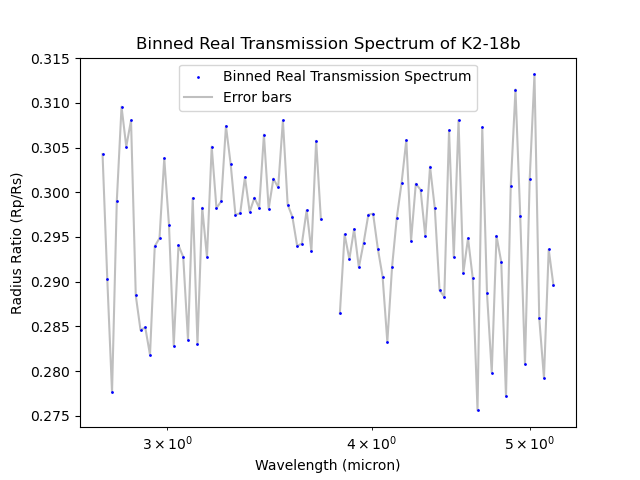

In [16]:
binned_fig = plt.figure()


wngrid = np.sort(10000/np.logspace(2.5,5.4,1000))
bn = SimpleBinner(wngrid=wngrid)

bin_wn, bin_rprs, bin_err,_  = bn.bindown(data[:,0], data[:,1], data[:,2])

plt.scatter(bin_wn, bin_rprs, label='Binned Real Transmission Spectrum', c='b', s=1, zorder=1)
plt.errorbar(bin_wn, bin_rprs, yerr=bin_err, label='Error bars', c='k', markersize=2, alpha=0.25, elinewidth=0.25, zorder=-1)
plt.xscale('log')
plt.title('Binned Real Transmission Spectrum of K2-18b')
plt.xlabel('Wavelength (micron)')
plt.ylabel('Radius Ratio (Rp/Rs)')
plt.legend()
plt.show()

In [ ]:
# binned_fig.savefig('K2-18b_assignment3_taskB_spectrum.png')